# TrustLens: Model Analysis Demo
This notebook demonstrates how to evaluate the trustworthiness of an ML model using TrustLens.
TrustLens goes beyond standard accuracy metrics to uncover calibration, bias, and confidence issues.

## 1. Installation
First, install the library.

In [ ]:
!pip install trustlens tqdm matplotlib scikit-learn

## 2. Quick Analysis (Zero-Friction Entry)
Try TrustLens instantly with `quick_analyze`. It auto-loads a sample dataset if you don't provide one, making it easy to see the output immediately.

In [1]:
%matplotlib notebook
%matplotlib ipympl
from trustlens import quick_analyze

# Run a complete analysis on the breast cancer dataset instantly
report_quick = quick_analyze(dataset="breast_cancer")


TrustLens Analysis: breast_cancer
Status: Loading demo model and breast_cancer validation data...
Running calibration analysis...
Running failure analysis...
Running bias analysis...

TrustLens Analysis Report
Timestamp : 2026-04-26T05:05:56.725827+00:00
Model     : LogisticRegression
Samples   : 171
Classes   : 2

TRUST SCORE: 68/100 [D]
Assessment : Low Trust - Blocked by high diagnostic risk (misaligned confidence-weighted error distribution)

Score Summary:
  Base Score        : 76
  Penalties Applied : -7.7 [Failure (-7.7)]
  Final Score       : 68

Score Explanation:
  - Dominant Issue  : Failure (-7.7)

Key Observations:
- Critical: High failure risk detected (2% error rate).
    → Heavily penalized because errors are dangerously concentrated in the ~0.76 confidence range.
- ℹ Info: Calibration quality is excellent (score 90+).
- ℹ Info: No bias detected (margin: 0.10 from 0.10 limit).

Dimension Breakdown:
- Calibration Score :  93.5/100
- Failure Score     :  36.8/100
- Bias 

/home/shahid/Desktop/TrustLens/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:394: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 3. Rich UI Integration
TrustLens supports **Rich Jupyter Display**. Simply typing `report` in a cell will render a styled dashboard with the Trust Score, grade, and key observations.

TrustReport(model='LogisticRegression', score=68/100 [D], samples=171, modules=[calibration, failure, bias])
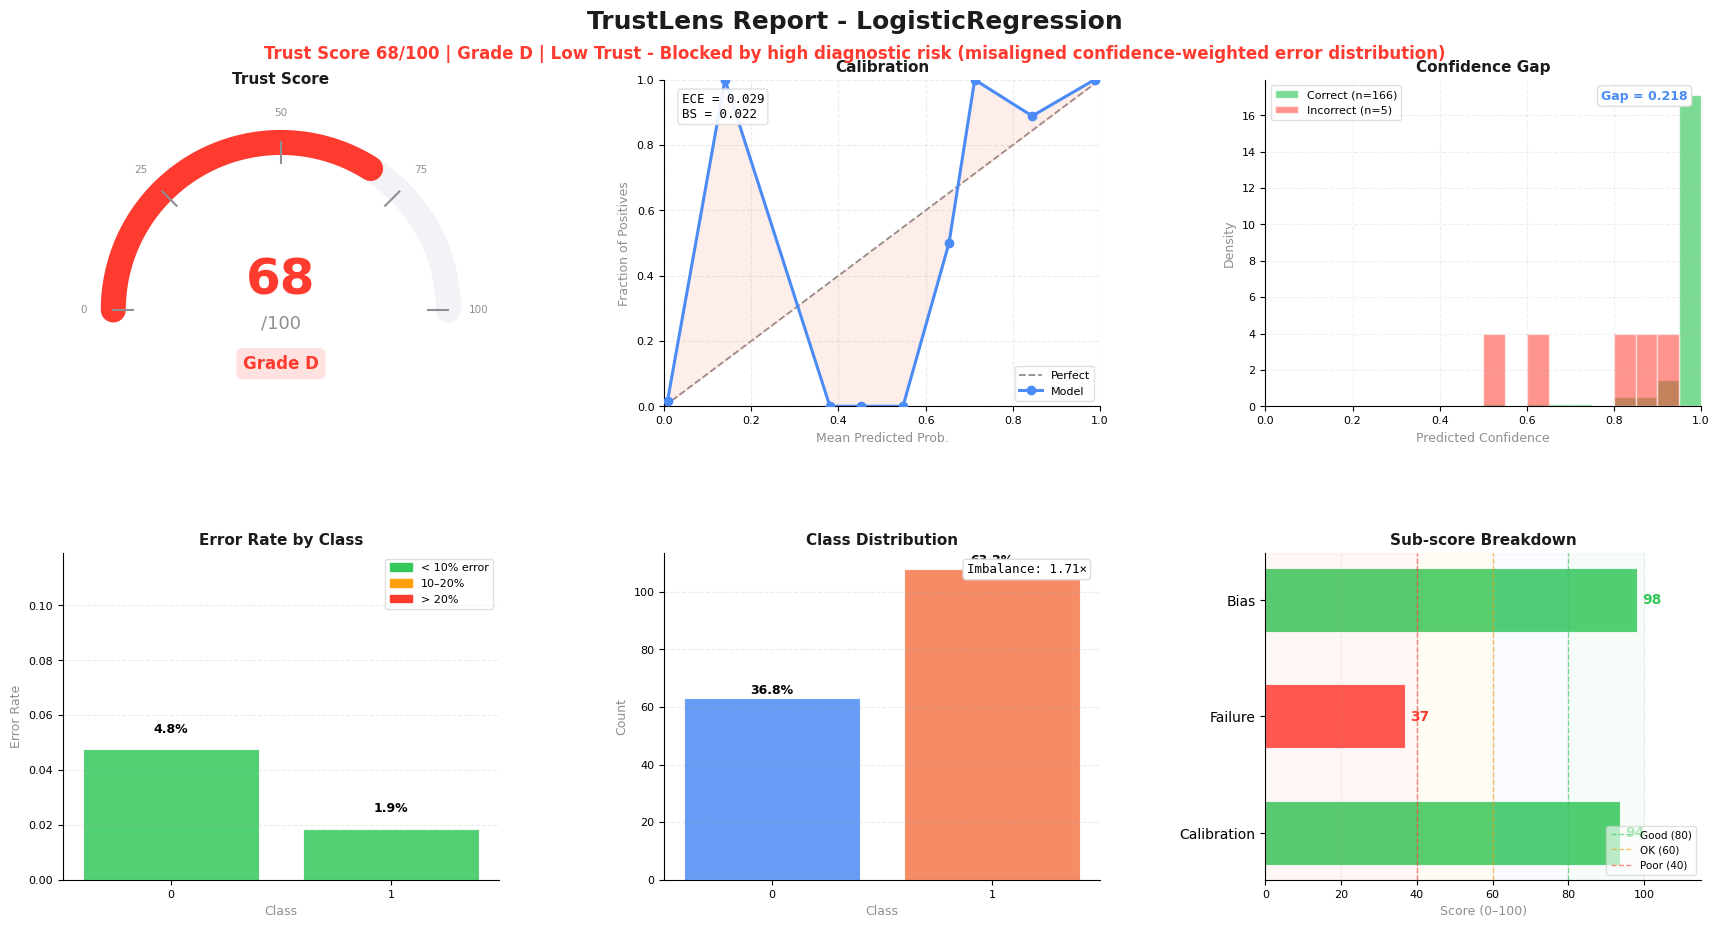

In [2]:
# This will render the styled HTML dashboard automatically
report_quick

## 4. Custom Model Analysis
For your own models, step through data preparation and analysis manually.

In [3]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from trustlens import analyze

# Generate synthetic dataset with class imbalance (80/20)
X, y = make_classification(n_samples=2000, n_features=20, n_classes=2, weights=[0.8, 0.2], random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Add a sensitive feature for bias detection
age_group = np.random.choice(['18-30', '31-50', '51+'], size=len(y_val))

# Train Model
model = RandomForestClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Run Analysis with sensitive features
report = analyze(
  model, 
  X_val, 
  y_val, 
  sensitive_features={"age_group": age_group}
)

Running calibration analysis...
Running failure analysis...
Running bias analysis...


## 5. Failure Analysis
Identify high-confidence mistakes where the model is 'certain' but wrong.

In [4]:
report.show_failures(top_k=5)


CRITICAL FAILURES
RandomForestClassifier | 40 total errors / 600 samples (6.7%)

#    Sample     True   Pred   Confidence   Danger
1    144           1      0       99.3% CRITICAL
2    232           1      0       93.6%     HIGH
3    433           1      0       90.5%     HIGH
4    489           1      0       87.0%     HIGH
5    100           1      0       85.9%     HIGH

 Insights:
   Mean confidence on top failures: 91.3%
   These are high-confidence mistakes - the model is
   certain it is right, but it is wrong.
   Overconfidence detected - consider calibration.



In [7]:
report.show()


TrustLens Analysis Report
Timestamp : 2026-04-26T05:06:10.871156+00:00
Model     : RandomForestClassifier
Samples   : 600
Classes   : 2

TRUST SCORE: 63/100 [D]
Assessment : Low Trust - Blocked by high diagnostic risk (misaligned confidence-weighted error distribution)

Score Summary:
  Base Score        : 71
  Penalties Applied : -8.2 [Failure (-8.2)]
  Final Score       : 63

Score Explanation:
  - Dominant Issue  : Failure (-8.2)

Key Observations:
- Critical: High failure risk detected (6% error rate).
    → Heavily penalized because errors are dangerously concentrated in the ~0.71 confidence range.
- Warning: Calibration is acceptable (score 75-89), but could be improved.
- ℹ Info: No bias detected (margin: 0.07 from 0.10 limit).

Dimension Breakdown:
- Calibration Score :  88.3/100
- Failure Score     :  35.3/100
- Bias Score        :  89.6/100

Calibration Analysis
- Brier Score: 0.0482
- Ece: 0.0459

Conclusion:
Model shows high failure risk and is not ready for deployment.

[

## 6. Sub-Score Details
You can also inspect the individual Trust Score result object for a compact styled breakdown.

In [5]:
report.trust_score

TrustScoreResult(score=63, grade='D')

## 7. Persisting Reports
Save the entire report (JSON results, metadata, and all plots) to a directory for later review or CI/CD integration.

In [6]:
report.save("trustlens_audit_report")

PosixPath('/home/shahid/Desktop/TrustLens/examples/trustlens_audit_report')